In [2]:
import sqlite3
import pandas as pd
con = sqlite3.connect(r'C:\Users\ishan\OneDrive\Desktop\project_3.1\data\raw\ipl.db')

import matplotlib.pyplot as plt

def q(sql):
    return pd.read_sql(sql, con)

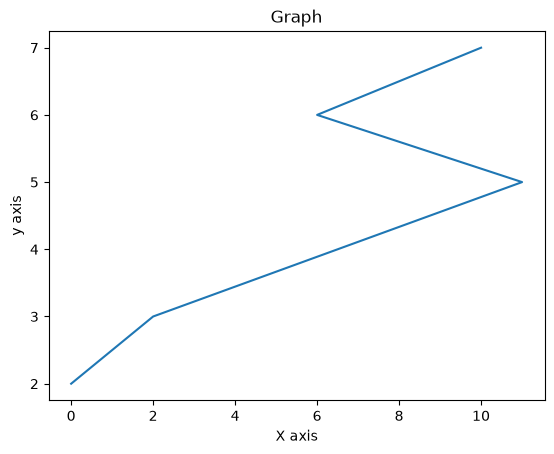

In [3]:
x = [0,2,11,6,10]
y = [2,3,5,6,7]

plt.plot(x,y)
plt.title('Graph')
plt.xlabel("X axis")
plt.ylabel("y axis")
plt.show()

<Axes: title={'center': 'Total balls in each phases'}, xlabel='Different phases of Innings', ylabel='Tital number of balls'>

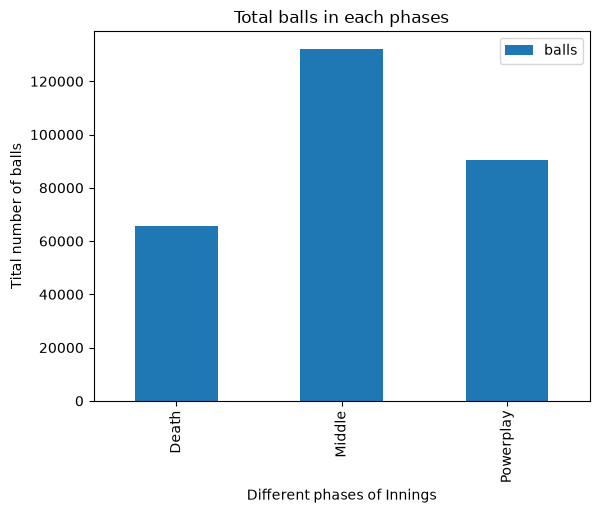

In [13]:
df = pd.read_sql("""select phase, count(*) as balls from v_ball group by phase;""", con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="Total balls in each phases",
        xlabel="Different phases of Innings",
        ylabel="Tital number of balls")

<Axes: title={'center': 'Top 5 Venues by Number of Matches'}, xlabel='Total Number of Matches', ylabel='Venue'>

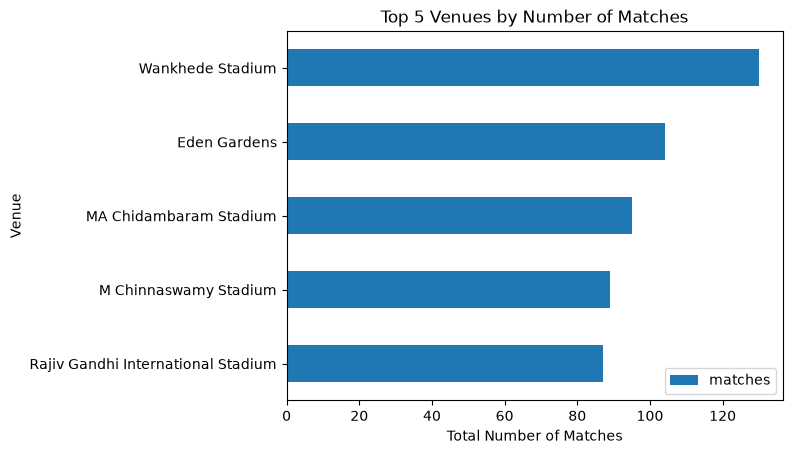

In [14]:
df = pd.read_sql("""SELECT venue_clean, COUNT(*) AS matches
FROM v_matches_venue
GROUP BY venue_clean
ORDER BY matches DESC
LIMIT 5;""", con).sort_values("matches")

df.plot(kind="barh",
        x="venue_clean",
        y="matches",
        title="Top 5 Venues by Number of Matches",
        xlabel="Total Number of Matches",
        ylabel="Venue")

<Axes: title={'center': 'Top 10 Batters by Number of Sixes'}, xlabel='Batters', ylabel='Total Number of Sixes'>

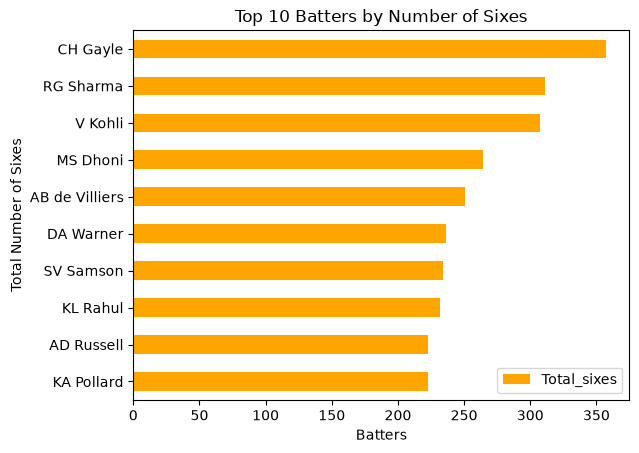

In [18]:
df = pd.read_sql("""SELECT batter,
       SUM(CASE WHEN batter_runs=6
                THEN 1
                ELSE 0
           END) AS Total_sixes
FROM v_ball
GROUP BY batter
ORDER BY Total_sixes DESC
LIMIT 10;""", con).sort_values("Total_sixes")

df.plot(kind="barh",
        x="batter",
        y="Total_sixes",
        title="Top 10 Batters by Number of Sixes",
        xlabel="Batters",
        ylabel="Total Number of Sixes",
        color="orange")

<Axes: title={'center': 'Distribution of Pace and Spin Deliveries'}>

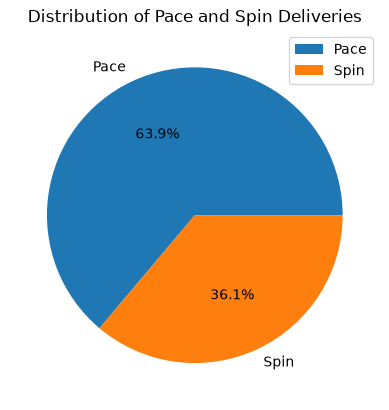

In [22]:
df = pd.read_sql("""SELECT CASE WHEN bowler_type LIKE
       '%Legbreak%' OR bowler_type LIKE
       '%Offbreak%' OR bowler_type LIKE
       '%Orthodox%' OR bowler_type LIKE
       '%Wrist spin%' OR bowler_type LIKE
       '%Googly%' THEN 'Spin' ELSE 'Pace'
       END AS style,
       SUM(is_legal) AS balls
FROM v_ball
WHERE bowler_type IS NOT NULL
AND TRIM(bowler_type) <> ''
GROUP BY style;""", con)

df.plot(kind="pie",
        y="balls",
        labels=df["style"],
        title="Distribution of Pace and Spin Deliveries",
        autopct="%1.1f%%")

<Axes: title={'center': 'Balls Faced vs Runs Scored'}, xlabel='Batter', ylabel='Count'>

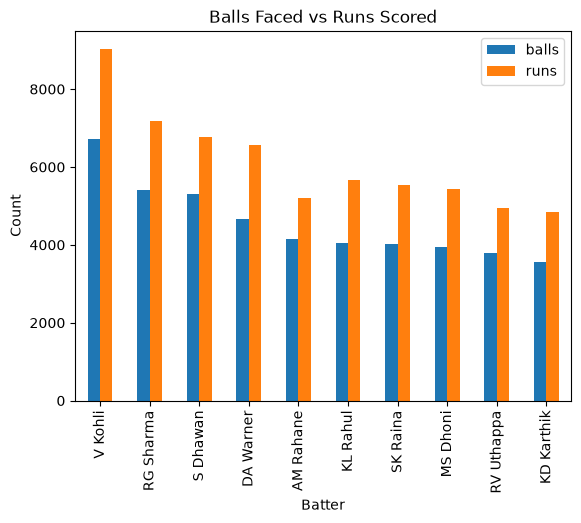

In [29]:
df = q("""SELECT batter, 
       SUM(is_legal) AS balls,
       SUM(batter_runs) AS runs,
       ROUND(100.0 * SUM(batter_runs) / SUM(is_legal), 2) AS strike_rate
FROM v_ball
GROUP BY batter
ORDER BY balls DESC
LIMIT 10;""")

df.plot(kind="bar",
        x="batter",
        y=["balls", "runs"],
        title="Balls Faced vs Runs Scored",
        xlabel="Batter",
        ylabel="Count")

<Axes: title={'center': 'Wicket Distribution by Type'}>

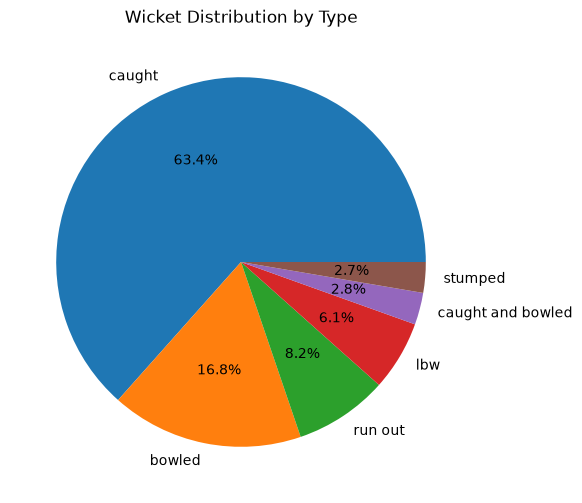

In [47]:
df = q("""
SELECT wicket_kind, COUNT(*) AS wickets
FROM v_ball
WHERE wicket_kind IS NOT NULL
GROUP BY wicket_kind
ORDER BY wickets DESC
LIMIT 6;
""")

df.plot(kind="pie",
        y="wickets",
        labels=df["wicket_kind"],
        title="Wicket Distribution by Type",
        autopct="%1.1f%%",
        figsize=(6,6),
        legend=False)

<Axes: title={'center': 'Top 10 Players by Player of the Match Awards'}, xlabel='Player', ylabel='Awards Won'>

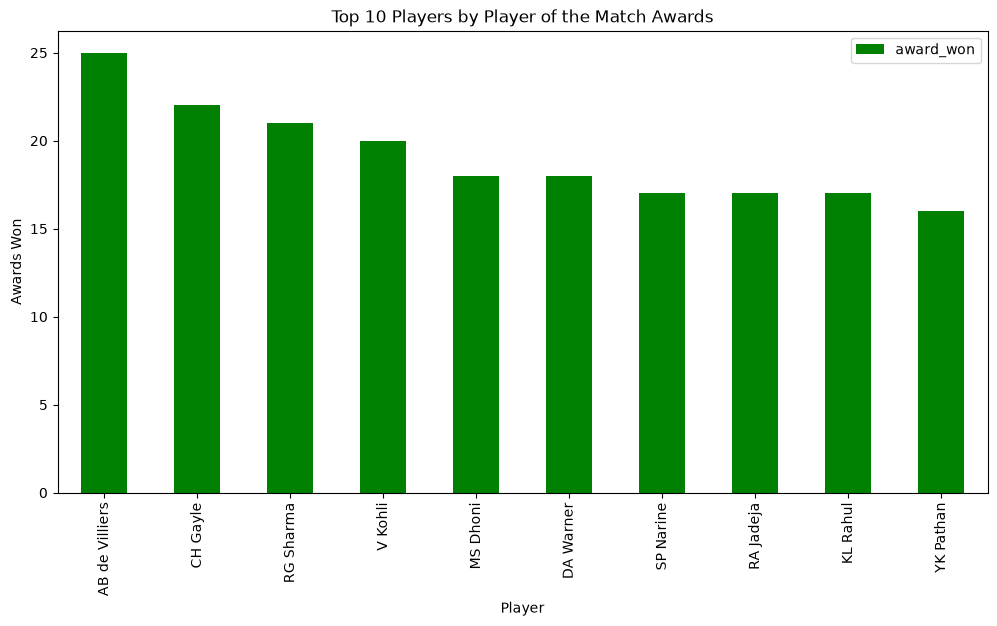

In [45]:
df = q("""
SELECT player_of_match,
       COUNT(*) AS award_won
FROM matches_clean
GROUP BY player_of_match
ORDER BY award_won DESC
LIMIT 10;
""")

df.plot(kind="bar",
        x="player_of_match",
        y="award_won",
        title="Top 10 Players by Player of the Match Awards",
        xlabel="Player",
        ylabel="Awards Won",
        figsize=(12,6),
        color="green")